In [1]:
import sys
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data
from src.visualizer import plot_daily_candlestick
from src.features import create_features
from src.risk_manager import evaluate_trade_risk
from src.label import create_labels

from sklearn.model_selection import TimeSeriesSplit

In [2]:
# Set tanggal dinamis (Contoh: Menarik data dari 6 bulan lalu hingga hari ini)
hari_ini = datetime.now().strftime('%Y-%m-%d')
lima_hari_lalu = (datetime.now() - timedelta(days=5)).strftime('%Y-%m-%d')
enam_bulan_lalu = (datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d')
sepuluh_tahun_lalu = (datetime.now() - timedelta(days=3650)).strftime('%Y-%m-%d')

start_date = "2015-01-01"
start_date_adj = "2014-12-01"  # Dilakukan adjustment untuk perlakuan NaN di awal (feature) dan di akhir (label)
cek_date = "2026-06-01"

# 1. Panggil data BUMI riil dari Bursa Efek Indonesia (.JK)
# Data ini mencerminkan kondisi pasar riil akhir periode bursa
df_bumi = load_stock_data(ticker="BUMI.JK", start_date=start_date_adj, end_date=hari_ini)
# ------------------------------------------

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 2840 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 123 baris data (NaN atau Volume 0).
Berhasil memuat 2717 baris data bersih untuk BUMI.JK.


In [3]:
print(df_bumi)

             Open   High    Low  Close        Volume
Date                                                
2014-12-01   87.0   87.0   77.0   82.0  3.307209e+08
2014-12-02   83.0   92.0   81.0   86.0  3.096259e+08
2014-12-03   87.0   88.0   81.0   81.0  2.070553e+08
2014-12-04   81.0   82.0   75.0   78.0  2.192481e+08
2014-12-05   78.0   81.0   76.0   78.0  8.804910e+07
...           ...    ...    ...    ...           ...
2026-06-15  165.0  191.0  163.0  173.0  1.333560e+10
2026-06-17  175.0  178.0  165.0  168.0  4.078183e+09
2026-06-18  169.0  173.0  163.0  171.0  2.760389e+09
2026-06-19  172.0  177.0  167.0  168.0  2.642491e+09
2026-06-22  170.0    NaN    NaN    NaN           NaN

[2718 rows x 5 columns]


Data terlalu banyak (2717 baris), melakukan binning bulanan...
Menghasilkan grafik candlestick bulanan untuk BUMI...


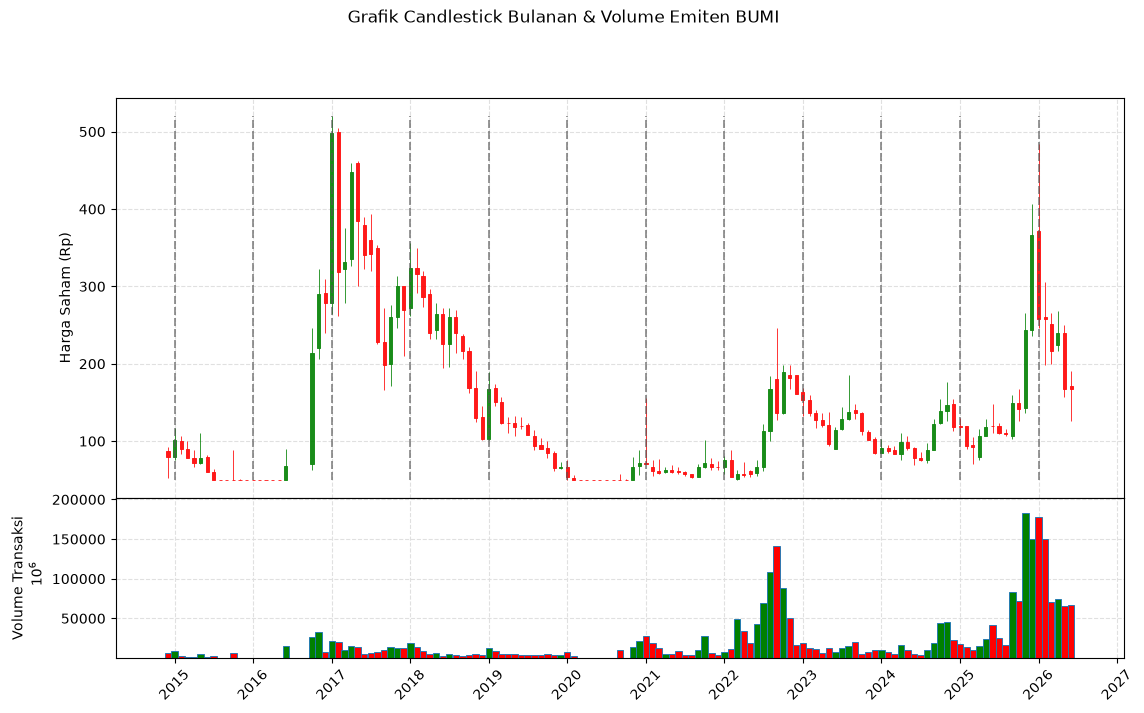

In [4]:
plot_daily_candlestick(df=df_bumi, ticker_name="BUMI")

In [5]:
# df_bumi = calculate_atr(df_bumi)
# latest_data = df_bumi.iloc[-1]
# current_close = float(latest_data['Close'])
# current_atr = float(latest_data['ATR'])

# resisten_terdekat = 186.0  

# trade_analysis = evaluate_trade_risk(
#     entry_price=current_close,
#     atr=current_atr,
#     resistance_level=resisten_terdekat,
#     min_rr_ratio=2.0
# )

# # Cetak Hasil Validasi Hitam-di-Atas-Putih
# print("=== LIVE SYSTEM RISK EVALUATION ===")
# print(f"Harga Masuk Terkini     : Rp{trade_analysis['entry_price']}")
# print(f"Nilai Volatilitas (ATR) : Rp{round(current_atr, 2)}")
# print(f"Garis Aman Cut Loss (SL): Rp{trade_analysis['suggested_stop_loss']} (Terproteksi dari noise)")
# print(f"Target Resisten (TP)    : Rp{trade_analysis['target_profit_resistance']}")
# print(f"Rasio R-to-R Aktual     : {trade_analysis['actual_rr_ratio']}x")
# print("-----------------------------------")

# if trade_analysis['execute_trade']:
#     print("KEPUTUSAN SISTEM: ISI ORDER BELI! Matematika risiko mendukung penuh.")
# else:
#     print("KEPUTUSAN SISTEM: BLOKIR TRANSAKSI! Jarak ke resisten terlalu sempit, batalkan emosi Anda.")

## ADD LABELS & FEATURES

In [6]:
HORIZON = 5

df_bumi = load_stock_data(ticker="BUMI.JK", start_date=start_date_adj, end_date=hari_ini)
df_bumi = create_labels(df_bumi, HORIZON)
df_bumi = create_features(df_bumi)
df_bumi

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 2840 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 123 baris data (NaN atau Volume 0).
Berhasil memuat 2717 baris data bersih untuk BUMI.JK.


,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High,Support,Resistance,distance_to_support,distance_to_resistance
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,87.0,87.0,77.0,82.0,3.307209e+08,-0.018391,0.057471,-0.137931,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-02,83.0,92.0,81.0,86.0,3.096259e+08,-0.042169,0.108434,-0.168675,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-03,87.0,88.0,81.0,81.0,2.070553e+08,-0.029885,0.011494,-0.218391,1.0,5.0,...,NaN,0.047628,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-04,81.0,82.0,75.0,78.0,2.192481e+08,-0.029630,0.012346,-0.160494,1.0,4.0,...,NaN,-0.059898,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-05,78.0,81.0,76.0,78.0,8.804910e+07,-0.019231,0.038462,-0.141026,1.0,5.0,...,NaN,-0.037740,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,165.0,191.0,163.0,173.0,1.333560e+10,NaN,NaN,NaN,NaN,NaN,...,1.359440,0.114603,126.0,134.079011,215.920989,224.0,126.0,224.0,23.061767,30.861205
2026-06-17,175.0,178.0,165.0,168.0,4.078183e+09,NaN,NaN,NaN,NaN,NaN,...,2.494476,0.097046,126.0,135.268476,210.731524,220.0,126.0,220.0,29.372345,20.418013
2026-06-18,169.0,173.0,163.0,171.0,2.760389e+09,NaN,NaN,NaN,NaN,NaN,...,0.745104,-0.029328,126.0,134.899346,211.100654,220.0,126.0,220.0,25.278591,24.911629


In [7]:
df_bumi.head(10)

,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High,Support,Resistance,distance_to_support,distance_to_resistance
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,87.0,87.0,77.0,82.0,330720900.0,-0.018391,0.057471,-0.137931,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-02,83.0,92.0,81.0,86.0,309625900.0,-0.042169,0.108434,-0.168675,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-03,87.0,88.0,81.0,81.0,207055300.0,-0.029885,0.011494,-0.218391,1.0,5.0,...,NaN,0.047628,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-04,81.0,82.0,75.0,78.0,219248100.0,-0.029630,0.012346,-0.160494,1.0,4.0,...,NaN,-0.059898,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-05,78.0,81.0,76.0,78.0,88049100.0,-0.019231,0.038462,-0.141026,1.0,5.0,...,NaN,-0.037740,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-08,77.0,79.0,69.0,70.0,238157300.0,-0.001299,0.025974,-0.129870,1.0,4.0,...,NaN,0.000000,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-09,70.0,76.0,68.0,72.0,183254200.0,-0.010000,0.085714,-0.042857,1.0,3.0,...,NaN,-0.108214,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-10,71.0,74.0,69.0,69.0,101870800.0,-0.021127,0.042254,-0.112676,1.0,5.0,...,NaN,0.028171,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726
2014-12-11,69.0,72.0,67.0,71.0,118125700.0,-0.050725,0.043478,-0.188406,1.0,5.0,...,NaN,-0.042560,NaN,NaN,NaN,NaN,52.0,92.0,40.880243,9.017726


In [8]:
df_bumi.tail(10)

,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High,Support,Resistance,distance_to_support,distance_to_resistance
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-08,132.0,139.0,126.0,130.0,4.621182e+09,0.036364,0.227273,-0.045455,5.0,1.0,...,0.749406,-0.076161,137.0,145.001258,241.998742,250.0,137.0,250.0,-8.966307,83.332380
2026-06-09,130.0,148.0,129.0,146.0,5.625440e+09,0.051538,0.469231,-0.007692,5.0,1.0,...,1.111615,-0.066939,126.0,133.801090,230.198910,238.0,126.0,137.0,-2.840852,77.076084
2026-06-10,146.0,157.0,142.0,144.0,7.438604e+09,0.055479,0.308219,-0.068493,4.0,2.0,...,1.292543,0.116072,126.0,134.027612,229.972388,238.0,126.0,238.0,8.932777,57.515334
2026-06-11,144.0,147.0,136.0,140.0,2.994048e+09,0.050694,0.326389,-0.055556,3.0,1.0,...,1.601539,-0.013793,126.0,133.957264,230.042736,238.0,126.0,238.0,7.496970,59.751900
2026-06-12,144.0,162.0,143.0,157.0,6.630660e+09,0.013889,0.326389,-0.006944,2.0,1.0,...,0.638560,-0.028171,126.0,133.629628,224.370372,232.0,126.0,232.0,7.760533,55.812758
2026-06-15,165.0,191.0,163.0,173.0,1.333560e+10,NaN,NaN,NaN,NaN,NaN,...,1.359440,0.114603,126.0,134.079011,215.920989,224.0,126.0,224.0,23.061767,30.861205
2026-06-17,175.0,178.0,165.0,168.0,4.078183e+09,NaN,NaN,NaN,NaN,NaN,...,2.494476,0.097046,126.0,135.268476,210.731524,220.0,126.0,220.0,29.372345,20.418013
2026-06-18,169.0,173.0,163.0,171.0,2.760389e+09,NaN,NaN,NaN,NaN,NaN,...,0.745104,-0.029328,126.0,134.899346,211.100654,220.0,126.0,220.0,25.278591,24.911629
2026-06-19,172.0,177.0,167.0,168.0,2.642491e+09,NaN,NaN,NaN,NaN,NaN,...,0.501607,0.017700,126.0,134.379433,205.620567,214.0,126.0,214.0,27.995777,19.546841


## PIPELINE DATA

In [9]:
feature_cols = ['ATR', 'RSI', 'Volume_Ratio', 'Log_Return', 'distance_to_support', 'distance_to_resistance']
label_cols = ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']

# Satukan ke dalam satu dataset besar
df_base_clean = df_bumi.dropna()
X_clean = df_base_clean[feature_cols]
y_clean = df_base_clean[label_cols]

print(f"✔ Matriks Fitur Bersih (X_clean) siap! dengan {X_clean.shape} kolom.")
print(f"✔ Matriks Target Bersih (y_clean) siap! dengan {y_clean.shape} kolom.")

✔ Matriks Fitur Bersih (X_clean) siap! dengan (2693, 6) kolom.
✔ Matriks Target Bersih (y_clean) siap! dengan (2693, 5) kolom.


In [10]:
# Pastikan indeks data berbentuk DatetimeIndex
X_clean.index = pd.to_datetime(X_clean.index)
y_clean.index = pd.to_datetime(y_clean.index)

# 1. Isolasi Periode In-Sample (Train & Validation Base: 2015 - 2023)
X_in_sample = X_clean.loc[:'2023-12-31']
y_in_sample = y_clean.loc[:'2023-12-31']

# 2. Isolasi Periode Out-of-Sample (Test Set & Backtest Engine: 2024 - 2025)
# Data ini tidak boleh disentuh sedikit pun selama proses tuning hyperparameter
X_out_sample = X_clean.loc['2024-01-01':'2025-12-31']
y_out_sample = y_clean.loc['2024-01-01':'2025-12-31']

# 3. Live Paper Trading / Forward Test
X_forward = X_clean.loc['2026-01-01':]
y_forward = y_clean.loc['2026-01-01':]

print("=== CHECKPOINT REKAPITULASI PEMISAHAN DATA ===")
print(f"📊 Total Data Bersih    : {X_clean.shape[0]} baris")
print(f"📂 Data In-Sample       : {X_in_sample.shape[0]} baris (Awal bursa 2015 s.d Desember 2023)")
print(f"🔒 Data Out-of-Sample   : {X_out_sample.shape[0]} baris (Januari 2024 s.d Desember 2025)")
print(f"⏩ Data Forward Test    : {X_forward.shape[0]} baris (Januari 2026 s.d Akhir bursa tersedia 2026)")

=== CHECKPOINT REKAPITULASI PEMISAHAN DATA ===
📊 Total Data Bersih    : 2693 baris
📂 Data In-Sample       : 2119 baris (Awal bursa 2015 s.d Desember 2023)
🔒 Data Out-of-Sample   : 473 baris (Januari 2024 s.d Desember 2025)
⏩ Data Forward Test    : 101 baris (Januari 2026 s.d Akhir bursa tersedia 2026)


In [11]:
print("=== SKEMA WALK-FORWARD VALIDATION (EXPANDING WINDOW) ===")

N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

fold = 1
for train_index, val_index in tscv.split(X_in_sample):
    X_train_fold, X_val_fold = X_in_sample.iloc[train_index], X_in_sample.iloc[val_index]
    y_train_fold, y_val_fold = y_in_sample.iloc[train_index], y_in_sample.iloc[val_index]
    
    start_train = X_train_fold.index.min().strftime('%Y-%m-%d')
    end_train = X_train_fold.index.max().strftime('%Y-%m-%d')
    start_val = X_val_fold.index.min().strftime('%Y-%m-%d')
    end_val = X_val_fold.index.max().strftime('%Y-%m-%d')
    
    print(f"\n▶ [FOLD {fold}]")
    print(f"  └── 📈 Data Train (Expanding) : {start_train} s.d {end_train} ({X_train_fold.shape[0]} sampel)")
    print(f"  └── 🎯 Data Validation        : {start_val} s.d {end_val} ({X_val_fold.shape[0]} sampel)")
    fold += 1

=== SKEMA WALK-FORWARD VALIDATION (EXPANDING WINDOW) ===

▶ [FOLD 1]
  └── 📈 Data Train (Expanding) : 2015-01-02 s.d 2016-06-20 (354 sampel)
  └── 🎯 Data Validation        : 2016-06-21 s.d 2018-03-08 (353 sampel)

▶ [FOLD 2]
  └── 📈 Data Train (Expanding) : 2015-01-02 s.d 2018-03-08 (707 sampel)
  └── 🎯 Data Validation        : 2018-03-09 s.d 2019-08-29 (353 sampel)

▶ [FOLD 3]
  └── 📈 Data Train (Expanding) : 2015-01-02 s.d 2019-08-29 (1060 sampel)
  └── 🎯 Data Validation        : 2019-08-30 s.d 2021-02-08 (353 sampel)

▶ [FOLD 4]
  └── 📈 Data Train (Expanding) : 2015-01-02 s.d 2021-02-08 (1413 sampel)
  └── 🎯 Data Validation        : 2021-02-09 s.d 2022-07-22 (353 sampel)

▶ [FOLD 5]
  └── 📈 Data Train (Expanding) : 2015-01-02 s.d 2022-07-22 (1766 sampel)
  └── 🎯 Data Validation        : 2022-07-25 s.d 2023-12-29 (353 sampel)
